# 03 - Modeling & Evaluation
**Dataset:** NHANES 2017-2018 (preprocessed)

**Goal:** Train multiple models, compare performance, add SHAP explainability, and save the best model for Streamlit deployment.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
print("Libraries Loaded")

Libraries Loaded


### Loading Data

In [2]:
df = pd.read_csv('../data/nhanes_preprocessed.csv')

X = df.drop(columns=['Diabetes'])
y= df['Diabetes']

print(f"Feature Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts()}")
print(f"\nDiabetes rate: {round(y.mean()*100, 2)}%")

Feature Shape: (7354, 12)
Target Distribution:
Diabetes
0    6536
1     818
Name: count, dtype: int64

Diabetes rate: 11.12%


### Train Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(f"Train Size: {X_train.shape}")
print(f"Test Size: {X_test.shape}")
print(f"\nTrain Diabetes Rate: {round(y_train.mean()*100, 2)}%")
print(f"Test Diabetes Rate: {round(y_test.mean()*100, 2)}%")

Train Size: (5883, 12)
Test Size: (1471, 12)

Train Diabetes Rate: 11.12%
Test Diabetes Rate: 11.15%


### Class Imbalance Note

In [4]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class Imbalance Ratio: {round(ratio, 2)}:1")
print()
print("Strategy: class_weight='balanced' for LR and RF")
print("          scale_pos_weight for XGBoost")
print()
print("This tells each model to pay propotionally more attention to diabetic patients during training.")

Class Imbalance Ratio: 8.0:1

Strategy: class_weight='balanced' for LR and RF
          scale_pos_weight for XGBoost

This tells each model to pay propotionally more attention to diabetic patients during training.


### Training All 3 Models

In [5]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression Trained")

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Trained")

# XGBoost
xgb = XGBClassifier(scale_pos_weight=ratio, n_estimators=100, random_state=42, eval_metrics='logloss', verbosity=0)
xgb.fit(X_train, y_train)
print("XGBoost Trained")

Logistic Regression Trained
Random Forest Trained
XGBoost Trained


### Evaluating All Models

In [6]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        'Model': name,
        'Accuracy': round(report['accuracy'], 3),
        'Precision (Diabetic)': round(report['1']['precision'], 3),
        'Recall (Diabetic)': round(report['1']['recall'], 3),
        'F1 (Diabetic)': round(report['1']['f1-score'], 3),
        'ROC - AUC': round(roc_auc_score(y_test, y_prob), 3)
    })
    
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Diabetic),Recall (Diabetic),F1 (Diabetic),ROC - AUC
0,Logistic Regression,0.733,0.278,0.872,0.421,0.850
1,Random Forest,0.893,0.588,0.122,0.202,0.857
2,XGBoost,0.854,0.364,0.415,0.387,0.833


### ROC Curves

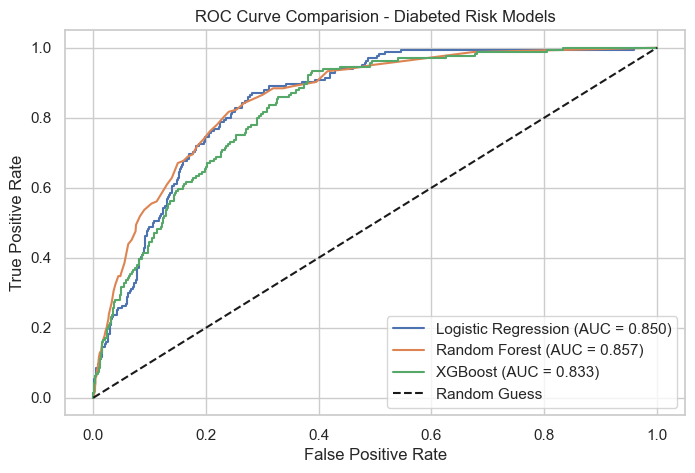

In [7]:
plt.figure(figsize=(8,5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparision - Diabeted Risk Models')
plt.legend()
plt.savefig('../data/roc_curve.png', bbox_inches='tight')
plt.show()

### Confusion Matrix for Best Model

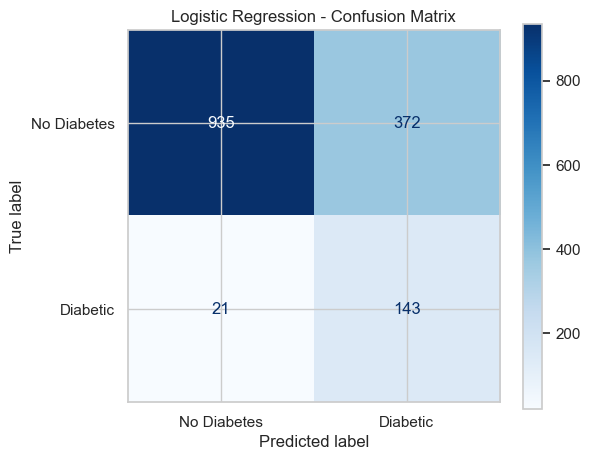

In [8]:
best_model = lr
best_name = 'Logistic Regression'

y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=['No Diabetes', 'Diabetic'], cmap='Blues', ax=ax)

plt.title(f"{best_name} - Confusion Matrix")
plt.savefig('../data/confusion_matrix.png', bbox_inches='tight')
plt.show()

### SHAP Explainability

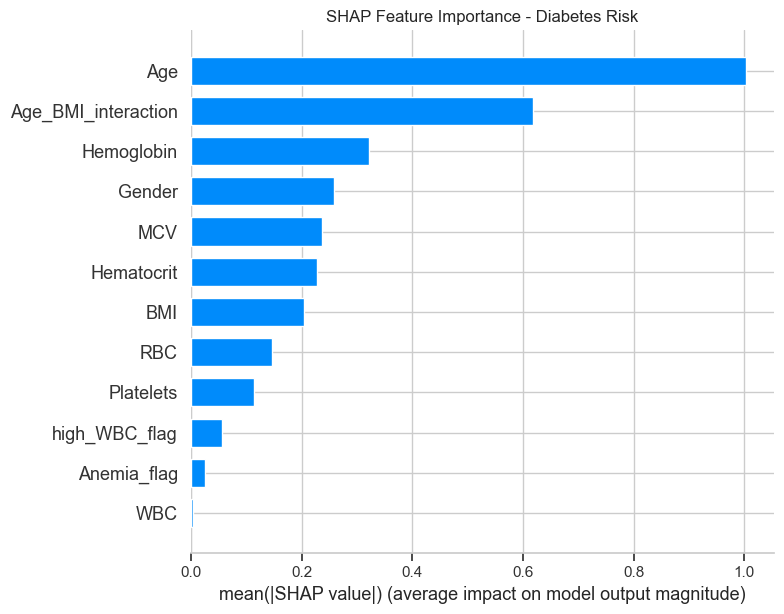

In [9]:
# LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Diabetes Risk')
plt.tight_layout()
plt.savefig('../data/shap_importance.png', bbox_inches='tight')
plt.show()

### SHAP dot Plot

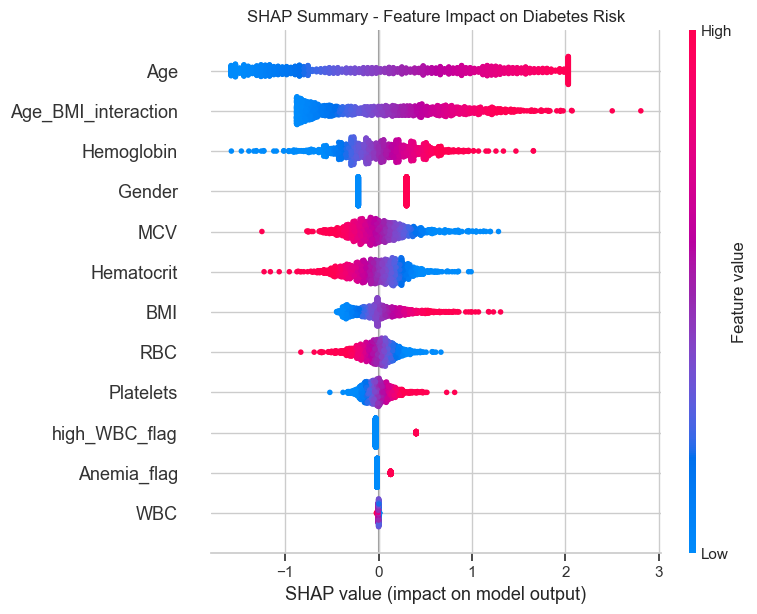

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary - Feature Impact on Diabetes Risk')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', bbox_inches='tight')
plt.show()

### Best Model Reference

In [11]:
y_prob_best = lr.predict_proba(X_test)[:, 1]

low = (y_prob_best < 0.3).sum()
medium = ((y_prob_best >= 0.3) & (y_prob_best < 0.6)).sum()
high = (y_prob_best >= 0.6).sum()

print("=" * 40)
print("   PATIENT RISK STRATIFICATION")
print("=" * 40)
print(f"Low Risk    (< 30%)  : {low} Patient")
print(f"Medium Risk (30-60%) : {medium} Patient")
print(f"High Risk   (>60%)   : {high} Patient")
print("=" * 40)
print(f"Total Test Patient   : {len(y_prob_best)}")

   PATIENT RISK STRATIFICATION
Low Risk    (< 30%)  : 752 Patient
Medium Risk (30-60%) : 299 Patient
High Risk   (>60%)   : 420 Patient
Total Test Patient   : 1471


### Saving the Best Model

In [12]:
best_model = lr
best_name = "Logistic Regression"

with open('../src/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
with open('../src/explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
    
print(f"{best_name} SAVED")
print("SHAP explainer SAVED")

Logistic Regression SAVED
SHAP explainer SAVED


## Modeling Summary

| Model | Accuracy | Recall (Diabetic) | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.733 | **0.872** | **0.850** |
| Random Forest | 0.893 | 0.122 | 0.857 |
| XGBoost | 0.854 | 0.415 | 0.833 |

**Best Model: Logistic Regression**
- Highest Recall (0.872) - catches 87% of actual diabetic patients
- Random Forest had 89% accuracy but only caught 12% of diabetics
  → Classic imbalanced data trap: high accuracy, clinically useless
- In clinical settings, a missed diabetic patient is far more costly
  than a false positive - Recall is the correct optimisation target

**Key SHAP Findings:**
- Age and BMI are the dominant risk predictors
- Age_BMI_interaction (engineered feature) contributed meaningfully
- Anemia_flag and High_WBC_flag added clinical signal

**Clinical Interpretation:**
Older patients with higher BMI and signs of anemia or chronic inflammation should be prioritised for diabetes screening - consistent with Type 2 diabetes risk guidelines.